In [1]:
# Importamos librerías
import numpy as np
import rasterio as rio
from rasterio.mask import mask
import geopandas as gpd
from scipy.ndimage import zoom
import matplotlib.pyplot as plt

### Import de bandas L8 (Córdóba) y vector área de estudio

In [79]:
# Vector área de estudio
study_area = gpd.read_file('sierras_fields.geojson')

# Bandas L8

# Lista de paths
list_paths = ['L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B4.TIF', 'L8/LC08_L2SP_229082_20170222_20200905_02_T1_SR_B5.TIF']


# Apertura, clip y guardadado de los datos de las bandas Red y NIR
list_arrays_bands = []

mask_transform = None

for p in list_paths:
    
    band_ds = rio.open(p)
    
    study_read_repj = study_area.to_crs(epsg=band_ds.crs.to_epsg())
    
    band_mask, mask_transform = mask(dataset=band_ds, shapes=study_read_repj.geometry, nodata=None, crop=True)
    
    list_arrays_bands.append((band_mask*2.75e-05)-0.02)
    
# Convierto a numpy da
array_bands_rn = np.array(list_arrays_bands)

In [82]:
# Cómputo de array de NDVI
ndvi_array = (array_bands_rn[1]-array_bands_rn[0])/(array_bands_rn[1]+array_bands_rn[0])
ndvi_array = np.where(ndvi_array <= 0, np.nan, ndvi_array)

### Import datos complementarios: DEM, A. urbanas y rutas provinciales 

In [85]:
# Lista path datos complementarios (raster)
list_paths_comp = ['comp_tifs/dem_studyarea.tif', 'comp_tifs/urban_prox.tif', 'comp_tifs/rutas_prov_proc.tif']

# Lectura de los datos y resampleo

# Guardar dimensiones array ndvi
n, m = ndvi_array[0].shape  # from your other array

# Operación sobre los datos
list_arrays_comp = [] # dem, urb_prox, roads_prox

for pc in list_paths_comp:
    
    comp_ds = rio.open(pc)
    #print(comp_ds.read().shape)
    comp_da = comp_ds.read()[0]
    #print(comp_da.shape)
    #comp_da_norm = (comp_da-np.nanmin(comp_da))/(np.nanmax(comp_da)-np.nanmin(comp_da))
    
    # --
    j, k = comp_da.shape
    zoom_factors = (n / j, m / k)
    
    # --
    list_arrays_comp.append(zoom(comp_da, zoom_factors, order=1)) # order = 1; biliear method
    #print(zoom(comp_da, zoom_factors, order=1).shape)

# Generación de array datos complementarios resampleado
array_comp = np.array(list_arrays_comp)

In [86]:
# Get slopes
dem_data = array_comp[0, :, :]

dem_data_copy = dem_data.copy()

rows, cols = dem_data.shape

delta_px = 30 # m

for c in range(1, cols-1):
    for r in range(1, rows-1):
        
        dd_dx = (dem_data[r, c+1]-dem_data[r, c-1])/delta_px*2
        dd_dy = (dem_data[r+1, c]-dem_data[r-1, c])/delta_px*2
        
        slope = np.sqrt(dd_dx**2+dd_dy**2)
        #print(slope)
        dem_data_copy[r, c] = slope
        
slope_data = dem_data_copy.copy()

In [90]:
# Cambio DEM por Slopes
#array_comp_full = np.concatenate([array_comp, slope_data[np.newaxis, :, :]], axis=0) # DEM, URB_PROX, ROAD_PROX, SLOPE
array_comp_full = array_comp.copy()
array_comp_full[0, :, :] = slope_data # SLOPES, URB_PROX, ROAD_PROX, SLOPE

### Generación del cubo de datos final

In [91]:
array_full = np.concatenate([ndvi_array, array_comp_full], axis=0) # NDVI, SLOPE, URB_PROX, ROAD_PROX

 ### Cómputo del índice de Riesgo

 $R = A * V$ / $A: [0, 3]$ y $R: [0, 2]$

In [98]:
# Defino funciones para normalización de los datos

# Normaliza min-max; Min. val.:0 & Max. Val.:1
def minmax_norm(array_x):
    return (array_x-np.nanmin(array_x))/(np.nanmax(array_x)-np.nanmin(array_x))

# Normaliza min-max; Min. val.:1 & Max. Val.:0
def minmax_norm_opp(array_x):
    return 1 - minmax_norm(array_x)

# Normaliza percentil; percentiles bajo y alto definen 0 y 1 (robusto a outliers)
def percentile_norm(array_x, low=1, high=99):
    p_low = np.nanpercentile(array_x, low)
    p_high = np.nanpercentile(array_x, high)
    norm = (array_x - p_low) / (p_high - p_low)
    return np.clip(norm, 0, 1)

# Normaliza percentil invertida; Min. val.:1 & Max. val.:0
def percentile_norm_opp(array_x, low=1, high=99):
    return 1 - percentile_norm(array_x, low=low, high=high)

In [93]:
# Guardo los datos por variables
NDVI = array_full[0]
SLOPE = array_full[1]
URBN = array_full[2]
ROAD = array_full[3]

In [99]:
# Cómputo del I. de Riesgo

# Cómputo A y V
A = percentile_norm_opp(ROAD) + percentile_norm_opp(SLOPE) + percentile_norm_opp(URBN)
V = percentile_norm(NDVI) + percentile_norm(SLOPE)#ndvi_array_norm[0] + array_comp[0]

# Cómputo R
R = A * V

### Ploteo de los resultados

**Ploteo de los datos de input**

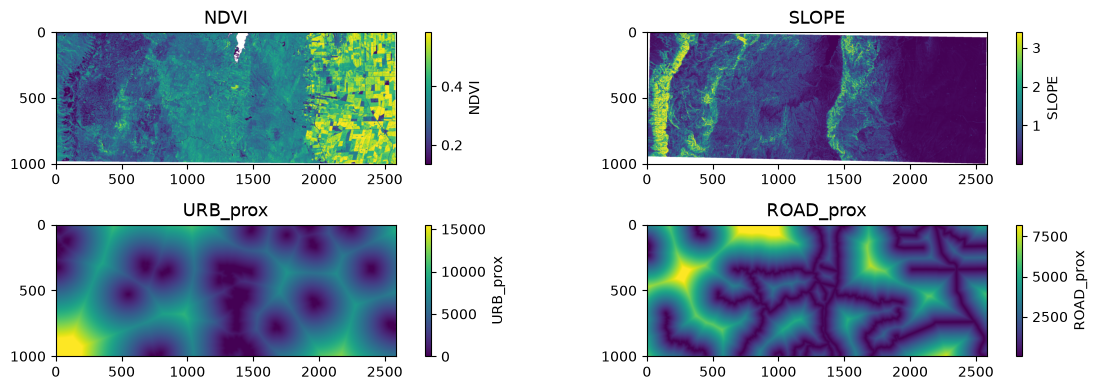

In [100]:
list_data = ['NDVI', 'SLOPE', 'URB_prox', 'ROAD_prox']

fig, ax = plt.subplots(2, 2, figsize=(12, 4), tight_layout=True)

ax = ax.flatten()

for idx, d in enumerate(list_data ):

    im = ax[idx].imshow(array_full[idx], vmin=np.nanpercentile(array_full[idx], 1), vmax=np.nanpercentile(array_full[idx], 99))
    fig.colorbar(im, ax=ax[idx], label=f'{list_data[idx]}')
    ax[idx].set_title(list_data[idx], fontsize=13)

**Ploteo de los mapas de A, V y R**

Text(0.5, 1.0, 'R Index Map')

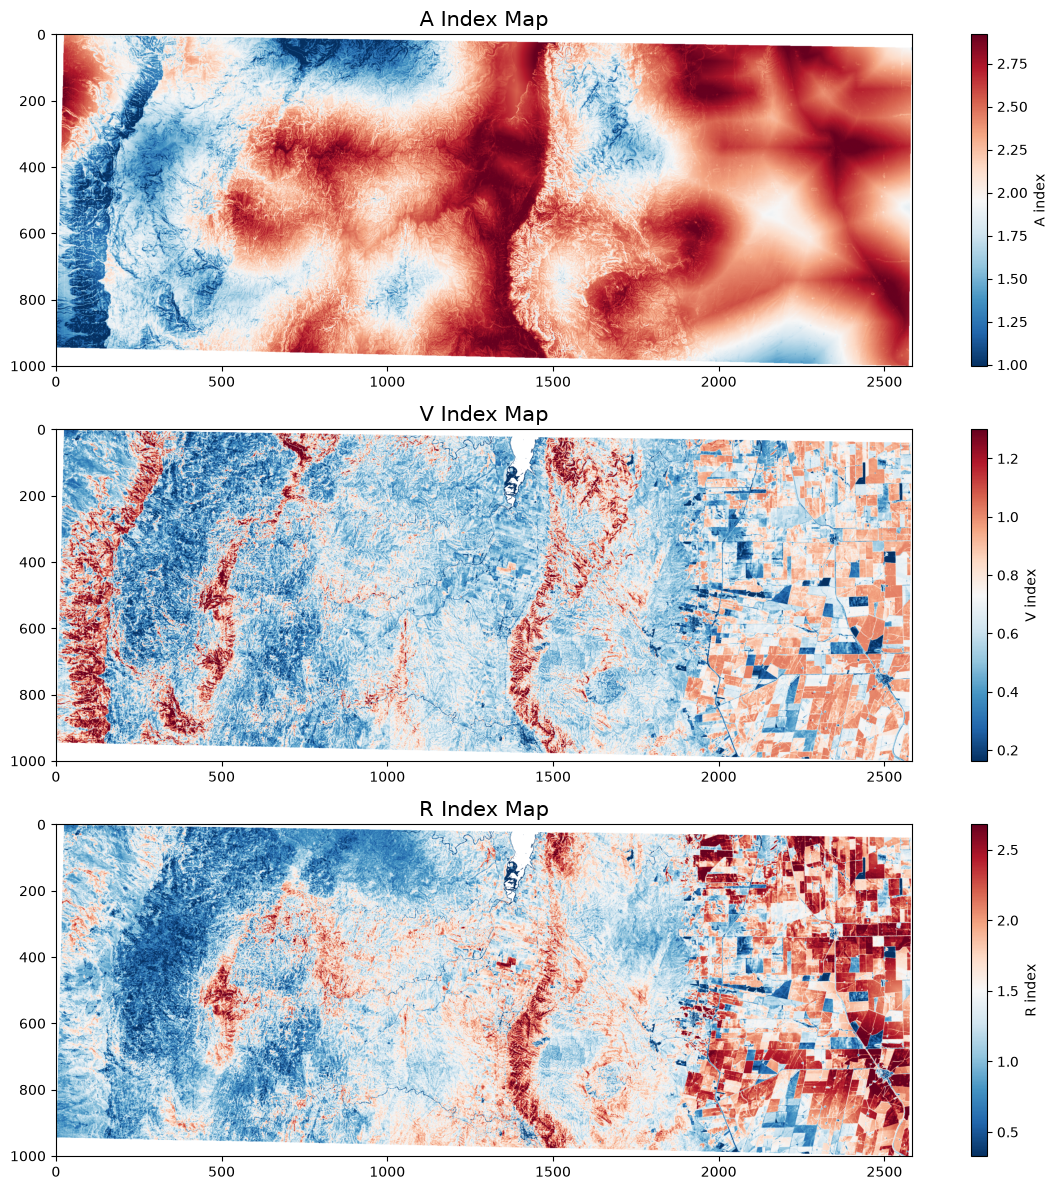

In [101]:
fig, ax = plt.subplots(3, 1, figsize=(12, 12), tight_layout=True)
ax = ax.flatten()

im = ax[0].imshow(A, cmap='RdBu_r', vmin=np.nanpercentile(A, 1), vmax=np.nanpercentile(A, 99))
fig.colorbar(im, ax=ax[0], label=f'A index')
ax[0].set_title('A Index Map', fontsize=15)

im = ax[1].imshow(V, cmap='RdBu_r', vmin=np.nanpercentile(V, 1), vmax=np.nanpercentile(V, 99))
fig.colorbar(im, ax=ax[1], label=f'V index')
ax[1].set_title('V Index Map', fontsize=15)

im = ax[2].imshow(R, cmap='RdBu_r', vmin=np.nanpercentile(R, 1), vmax=np.nanpercentile(R, 99))
fig.colorbar(im, ax=ax[2], label=f'R index')
ax[2].set_title('R Index Map', fontsize=15)

**Área de estudio**

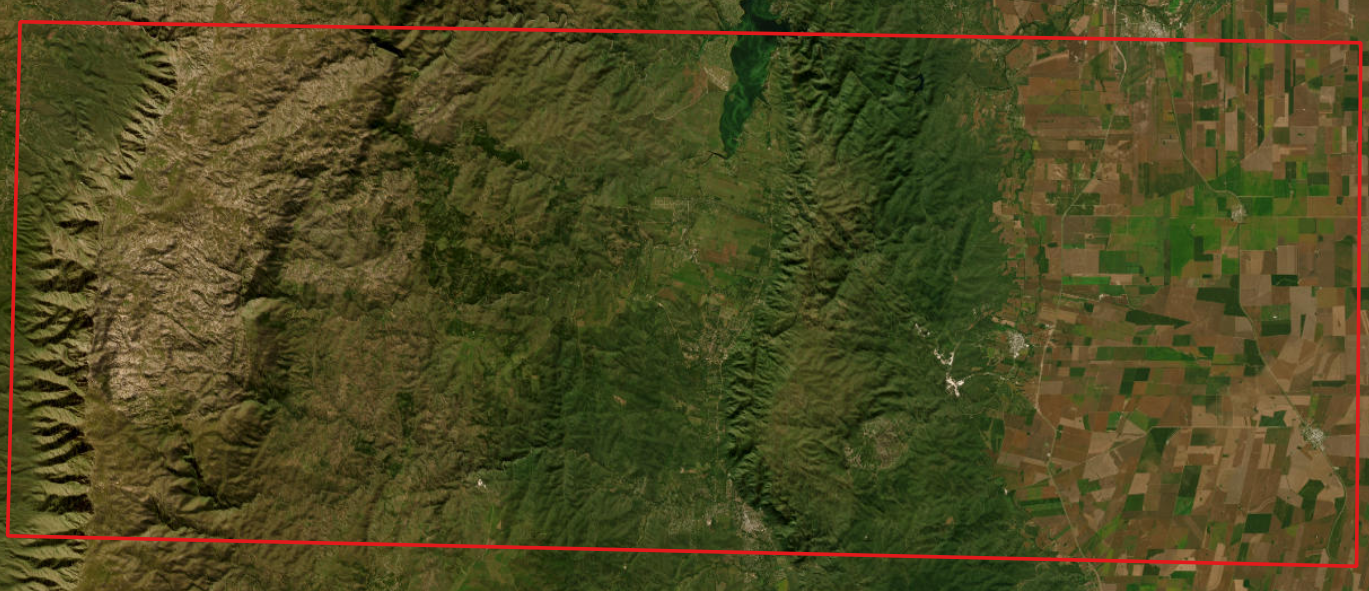